### **1. Setup & Imports**

This section handles the initial setup of the environment. It installs necessary Python packages, imports all required libraries from these packages

In [1]:
import random
import time
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [2]:
# ============================================================
# Check if current device is GPU
# ============================================================
if torch.cuda.is_available():
    print("Running on GPU!")
    DEVICE = torch.device("cuda")
else:
    print("Running on CPU!")
    DEVICE = torch.device("cpu")

# Set a global seed for reproducibility
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_global_seed(SEED)
print(f"Global random seed set to {SEED}")

Running on GPU!
Global random seed set to 42


### **2. Dataset Loading & EDA**
The dataset combines formal financial news sentences with short, informal stock market tweets, all labelled positive, negative, or neutral. [`Kaggle Dataset Link`](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis)

In [3]:
# Load data into dataframe
DATA_URL = (
    "https://raw.githubusercontent.com/faadeola/LLM-financial-sentiment-analysis/"
    "refs/heads/main/Financial%20Sentiment%20Analysis%20Data.csv"
)

df = pd.read_csv(DATA_URL)
print(f'The dataset contains{df.shape[0]} rows and {df.shape[1]} columns \n')
df.head()

The dataset contains5842 rows and 2 columns 



,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [4]:
# Display counts of labels
df["Sentiment"].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


/tmp/ipykernel_813/3678703001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='Blues_r')


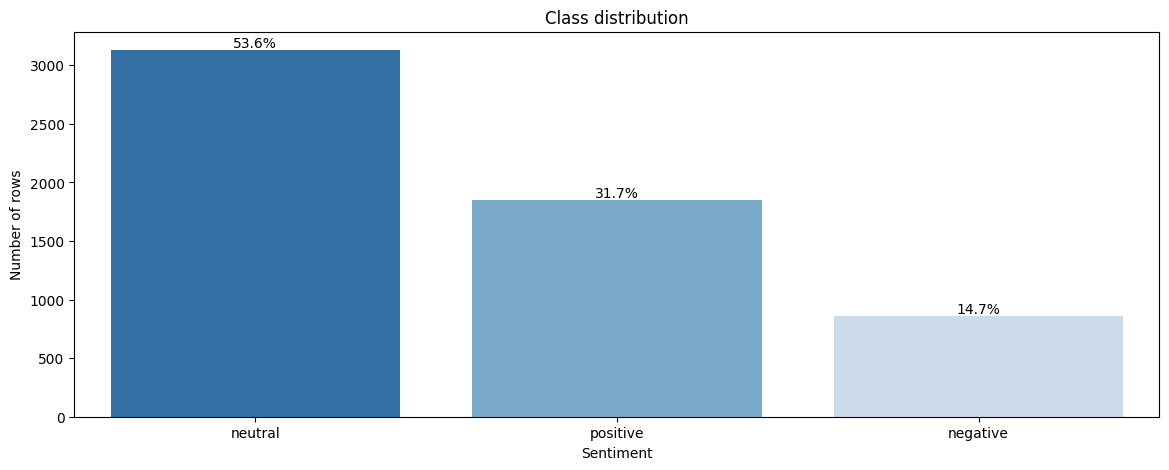

In [5]:
class_counts = df["Sentiment"].value_counts()
class_props = df["Sentiment"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='Blues_r')
ax.set_title("Class distribution")
ax.set_ylabel("Number of rows")
for i, (count, prop) in enumerate(zip(class_counts.values, class_props.values)):
    ax.text(i, count + 20, f"{prop:.1%}", ha="center")
plt.show()

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nExact duplicate rows (same sentence and same label):", df.duplicated().sum())
print("Duplicate sentences (any label):", df["Sentence"].duplicated().sum())

repeated = df[df["Sentence"].duplicated(keep=False)]
label_conflicts = repeated.groupby("Sentence")["Sentiment"].nunique()
label_conflicts = label_conflicts[label_conflicts > 1]
print("Sentences that appear more than once with different labels:", len(label_conflicts))

Missing values:
Sentence     0
Sentiment    0
dtype: int64

Exact duplicate rows (same sentence and same label): 6
Duplicate sentences (any label): 520
Sentences that appear more than once with different labels: 514


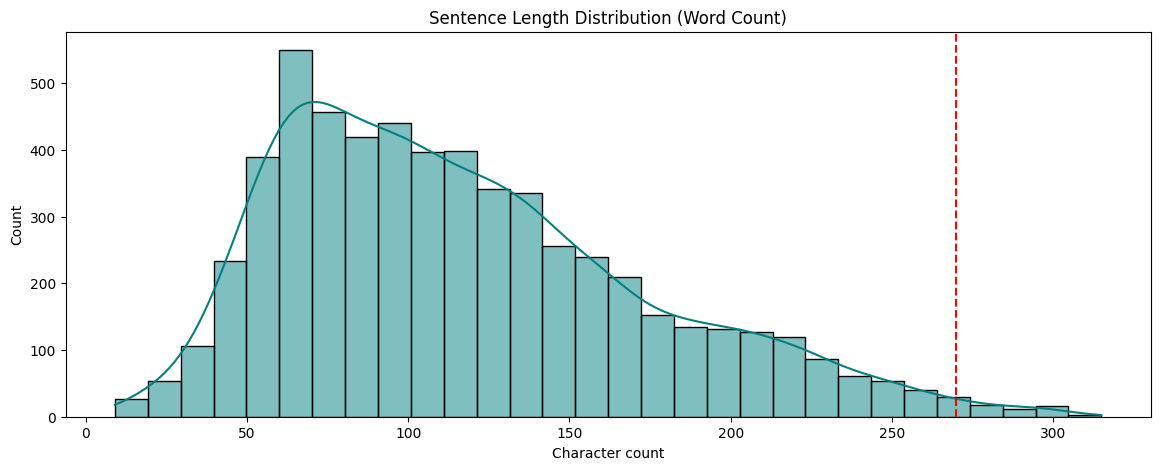

,char_length
count,5842.000000
mean,117.022253
std,56.420425
min,9.000000
25%,72.000000
50%,107.000000
75%,150.000000
max,315.000000


In [7]:
df["char_length"] = df["Sentence"].str.len()

fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(df["char_length"], ax=ax, kde=True, color='teal', bins=30)
plt.axvline(x=df["char_length"].quantile(0.99), color="red", linestyle="--", label='99th Percentile')
ax.set_title("Sentence Length Distribution (Word Count)")
ax.set_xlabel("Character count")
plt.show()

df["char_length"].describe()

In [8]:
# Flag sentence that contains tweet style format (hashtags)
tweet_pattern = r"\$[A-Za-z]+|https?://|#\w+"
df["looks_like_tweet"] = df["Sentence"].str.contains(tweet_pattern, regex=True)
df["looks_like_tweet"].value_counts()

,count
looks_like_tweet,
False,5167
True,675


### **3. Cleaning and Preprocessing**

In [9]:
# function to clean text in one go
def clean_text(text):
    """Basic text cleaning function for Transformer models."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()   # Remove redundant whitespace
    return text

In [10]:
df_clean = df.copy()
df_clean["Sentence"] = df_clean["Sentence"].apply(clean_text)

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Sentence", "Sentiment"]).reset_index(drop=True)
print(f"Rows before: {rows_before}, rows after cleaning and dropping exact duplicates: {len(df_clean)}")

df_clean = df_clean[["Sentence", "Sentiment"]].copy()

Rows before: 5842, rows after cleaning and dropping exact duplicates: 5831


In [12]:
label_encoder = LabelEncoder()
df_clean["label"] = label_encoder.fit_transform(df_clean["Sentiment"])

label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_map)

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [13]:

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df_clean["Sentence"].tolist(),
    df_clean["label"].tolist(),
    test_size=0.15,
    random_state=SEED,
    stratify=df_clean["label"],
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.15,
    random_state=SEED,
    stratify=train_val_labels,
)

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 4212, Val: 744, Test: 875
